# 06 — Biểu đồ so sánh model & đánh giá UNCERTAINTY

**Mục đích:** đáp ứng góp ý của mentor sau báo cáo tuần 2:

> *"nếu mà được thì 2 em có thêm plot khi mà so sánh các model nhé. Kiểu plot price over time hay
> multiplier over time anh nghĩ là sẽ informative hơn, với có cả vùng standard deviation nữa, để
> mình đánh giá được mức độ uncertainty."*

Notebook này **không train gì** — chỉ nạp lại dự đoán đã lưu, gắn thêm mốc thời gian rồi vẽ.

**Sinh ra 4 hình** (lưu vào `docs/hinh_anh/`, dùng cho mục 5 báo cáo tuần 2):

| Hình | Nội dung |
|---|---|
| `U1_gia_heso_theo_gio_std.png` | Giá & hệ số nhân **theo giờ**, có vùng ±1 std |
| `U2_chuoi_thoigian_std.png` | Giá & hệ số nhân **theo thời gian thực**, có vùng ±1 std |
| `U3_sosanh_model_saiso.png` | So sánh model: MAE theo giờ + phân bố sai số |
| `U4_uncertainty_batdoixung.png` | Bất đối xứng uncertainty: giá cơ bản vs hệ số nhân |

---

> ⚠️ **LƯU Ý QUAN TRỌNG VỀ NGUỒN DỮ LIỆU**
>
> Notebook này **KHÔNG** nạp `../<ThuatToan>/*.joblib`. Lý do: các file joblib hiện tại **không tái
> tạo được** số liệu trong báo cáo (đã kiểm chứng — nạp lại model hệ số nhân và dự đoán trên chính
> bộ feature đã lưu cho ra MAE 0,1351 / R² 0,034 thay vì 0,0233 / 0,961). Nhiều khả năng chúng đã
> bị ghi đè bởi một lần chạy thử nghiệm sau đó.
>
> **Các file `.parquet` dự đoán mới là artifact đúng** — đã đối chiếu khớp từng con số với báo cáo.
> Cell kiểm tra ở mục 2 sẽ tự động dừng nếu số liệu lệch.

## 1. Nạp dự đoán đã lưu & gắn mốc thời gian

**Nguồn dữ liệu:**

| File | Lấy gì |
|---|---|
| `pred_hybrid_cu.parquet` | `base_pred`, `mult_pred`, `hybrid_pred` |
| `pred_gia.parquet` | dự đoán giá trực tiếp (Hướng 1) |
| `../../data/hcm_train_ready.parquet` | `target_timestamp` — cột thời gian mà các file dự đoán không lưu |

**Cách ghép:** theo **vị trí**. Cả 3 file đều lấy `split=test` theo cùng thứ tự tháng, nên căn được
theo vị trí — có `assert` kiểm tra trên 4 cột chung, sai là dừng ngay.

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
%matplotlib inline

# Okabe-Ito (an toan voi nguoi mu mau) - dong bo voi cac hinh khac trong bao cao
BLUE, ORANGE, GREEN, RED, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#666666"
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)

ALGO = "HistGB"                       # thuat toan mac dinh da chot
HINH = Path("../../docs/hinh_anh")    # noi luu anh cho bao cao
HINH.mkdir(parents=True, exist_ok=True)

def metrics(y, p):
    y, p = np.asarray(y), np.asarray(p)
    return dict(MAE=mean_absolute_error(y, p), RMSE=mean_squared_error(y, p) ** .5,
                R2=r2_score(y, p), MAPE=np.mean(np.abs((y - p) / y)) * 100)

print("Da cau hinh. Thuat toan:", ALGO)

Da cau hinh. Thuat toan: HistGB


In [2]:
# --- 1a. Cot thoi gian tu train_ready, xep dung thu tu ma cac notebook train da dung ---
cols = ["split", "evaluation_month", "target_timestamp", "gio_vn", "thu_vn",
        "quote_distance", "quote_duration", "weather_main",
        "target_shown_price", "target_shown_multiplier", "persistence_prediction"]
d = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
te = d[d.split == "test"]
te = pd.concat([te[te.evaluation_month == th] for th in sorted(te.evaluation_month.unique())])
te = te.reset_index(drop=True)
del d
print(f"train_ready | split=test: {len(te):,} dong")

# --- 1b. Du doan Hybrid (base_pred / mult_pred / hybrid_pred) ---
ar = pd.read_parquet("pred_hybrid_cu.parquet")
ar = ar[ar.algo == ALGO].reset_index(drop=True)

# --- 1c. Du doan gia truc tiep (Huong 1) ---
gd = pd.read_parquet("pred_gia.parquet")
gd = gd[gd.algo == ALGO].reset_index(drop=True)

# --- 1d. Kiem tra ghep theo VI TRI (sai la dung ngay) ---
assert len(ar) == len(te) == len(gd), f"Lech so dong: {len(ar)} / {len(te)} / {len(gd)}"
for c in ["target_shown_price", "target_shown_multiplier", "quote_distance", "gio_vn"]:
    a = np.nan_to_num(te[c].values.astype("float64"))
    assert np.array_equal(a, np.nan_to_num(ar[c].values.astype("float64"))), f"Lech vi tri: {c} (archive)"
    if c in gd.columns:
        assert np.array_equal(a, np.nan_to_num(gd[c].values.astype("float64"))), f"Lech vi tri: {c} (pred_gia)"
print("Ghep theo vi tri: OK (da kiem tra 4 cot chung)")

train_ready | split=test: 864,360 dong


Ghep theo vi tri: OK (da kiem tra 4 cot chung)


In [3]:
# --- 1e. Gop thanh 1 bang danh gia duy nhat ---
ev = pd.DataFrame({
    "thoi_diem":      pd.to_datetime(te.target_timestamp),
    "thang":          te.evaluation_month.astype(str),
    "gio_vn":         te.gio_vn.astype(int),
    "quang_duong":    te.quote_distance.astype("float32"),
    "thoi_luong":     te.quote_duration.astype("float32"),
    "thoi_tiet":      te.weather_main.astype(str),
    # su that
    "gia_that":       te.target_shown_price.astype("float64"),
    "heso_that":      te.target_shown_multiplier.astype("float64"),
    "gia_coban_that": ar.base_price.astype("float64"),
    # du doan
    "gia_coban_dd":   ar.base_pred.astype("float64"),
    "heso_dd":        ar.mult_pred.astype("float64"),
    "hybrid_dd":      ar.hybrid_pred.astype("float64"),
    "tructiep_dd":    gd.pred.astype("float64"),
    "persistence":    te.persistence_prediction.astype("float64"),
})
# gio VN = UTC + 7 (du lieu goc la UTC)
ev["tg_vn"] = ev.thoi_diem + pd.Timedelta(hours=7)

# Sai so tung model
ev["e_hyb"] = ev.hybrid_dd - ev.gia_that
ev["e_tt"]  = ev.tructiep_dd - ev.gia_that
ev["e_per"] = ev.persistence - ev.gia_that

print(f"Bang danh gia: {len(ev):,} dong")
print("Khoang thoi gian:", ev.tg_vn.min(), "->", ev.tg_vn.max(), f"| {ev.tg_vn.dt.date.nunique()} ngay")
ev.head(3)

Bang danh gia: 864,360 dong


Khoang thoi gian: 2026-01-28 07:00:01+00:00 -> 2026-03-31 06:59:55+00:00 | 14 ngay


,thoi_diem,thang,gio_vn,quang_duong,thoi_luong,thoi_tiet,gia_that,heso_that,gia_coban_that,gia_coban_dd,heso_dd,hybrid_dd,tructiep_dd,persistence,tg_vn,e_hyb,e_tt,e_per
0,2026-01-28 00:00:07+00:00,2026-01,7,5.708,1018.409973,Rain,106000.0,1.18,89830.515625,87101.387739,1.152201,100358.305265,101627.679799,145000.0,2026-01-28 07:00:07+00:00,-5641.694735,-4372.320201,39000.0
1,2026-01-28 00:00:07+00:00,2026-01,7,5.708,1018.409973,Rain,106000.0,1.18,89830.515625,87002.542326,1.170802,101862.731497,99939.966800,74000.0,2026-01-28 07:00:07+00:00,-4137.268503,-6060.033200,-32000.0
2,2026-01-28 00:00:07+00:00,2026-01,7,5.708,1018.409973,Rain,106000.0,1.18,89830.515625,86953.070681,1.163376,101159.145110,101611.251495,93000.0,2026-01-28 07:00:07+00:00,-4840.854890,-4388.748505,-13000.0


## 2. Kiểm tra — số liệu phải khớp báo cáo

Cell này là **chốt an toàn**: nếu nguồn dữ liệu bị thay đổi/hỏng, các con số sẽ lệch và `assert`
dừng ngay, tránh vẽ ra biểu đồ sai.

In [4]:
bang = pd.DataFrame([
    {"Model": "Gia co ban (Model A)", **metrics(ev.gia_coban_that, ev.gia_coban_dd)},
    {"Model": "He so nhan (Model B)", **metrics(ev.heso_that, ev.heso_dd)},
    {"Model": "HYBRID (A x B)",       **metrics(ev.gia_that, ev.hybrid_dd)},
    {"Model": "Du doan truc tiep",    **metrics(ev.gia_that, ev.tructiep_dd)},
    {"Model": "Baseline persistence", **metrics(ev.gia_that, ev.persistence)},
]).round(4)
display(bang)

# Chot an toan - doi chieu voi bao cao tuan 2
assert abs(metrics(ev.gia_coban_that, ev.gia_coban_dd)["MAE"] - 15031.56) < 5,  "Gia co ban lech!"
assert abs(metrics(ev.heso_that, ev.heso_dd)["MAE"] - 0.0233) < 0.001,          "He so nhan lech!"
assert abs(metrics(ev.gia_that, ev.hybrid_dd)["MAE"] - 18047.97) < 5,           "Hybrid lech!"
assert abs(metrics(ev.gia_that, ev.tructiep_dd)["MAE"] - 18834.01) < 5,         "Truc tiep lech!"
print("\nOK - toan bo so lieu KHOP bao cao tuan 2.")

,Model,MAE,RMSE,R2,MAPE
0,Gia co ban (Model A),15031.5562,20076.6652,0.6563,14.5846
1,He so nhan (Model B),0.0233,0.0362,0.9606,1.9121
2,HYBRID (A x B),18047.9668,24533.9569,0.7297,14.7445
3,Du doan truc tiep,18834.0135,25644.7465,0.7047,15.3599
4,Baseline persistence,33683.2165,46734.4424,0.0191,28.1815



OK - toan bo so lieu KHOP bao cao tuan 2.


## 3. Hình U1 — Giá & hệ số nhân **theo giờ**, kèm vùng ±1 độ lệch chuẩn

Kiểm soát dải quãng đường **4–6 km** để loại ảnh hưởng của độ dài chuyến (đồng bộ với cách phân
tích ở các notebook `analysis/`).

**Cách đọc:** đường liền = thực tế, đường đứt = model, vùng mờ = ±1 std.
- Model bám sát đường trung bình → dự đoán đúng **xu hướng**.
- Vùng mờ của model **hẹp hơn** thực tế → model không tái tạo được **độ dao động** thật.

Dai 4-6km: 330,288 dong


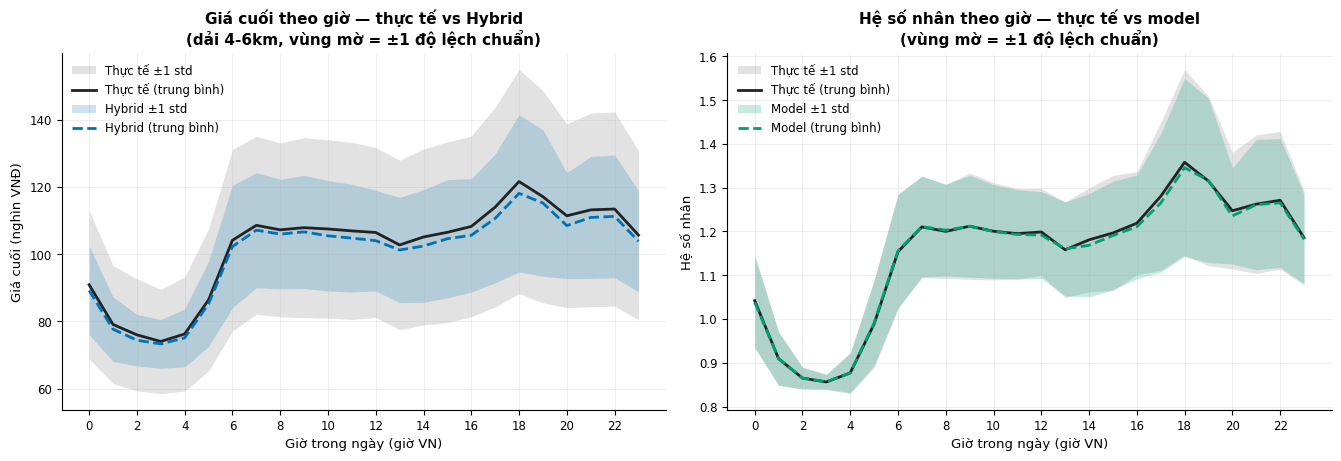

Bien do gia cuoi theo gio : 74.1k -> 121.6k (64.2%)
Bien do he so nhan        : 0.856 -> 1.358 (58.6%)
std TB gia   : that 25,161 | model 15,545 -> model HEP HON 38.2%
std TB heso  : that 0.1148 | model 0.1102 -> model HEP HON 3.9%


In [5]:
band = ev[(ev.quang_duong >= 4) & (ev.quang_duong <= 6)].copy()
print(f"Dai 4-6km: {len(band):,} dong")

g = band.groupby("gio_vn")
m_that, s_that = g.gia_that.mean(), g.gia_that.std()
m_hyb,  s_hyb  = g.hybrid_dd.mean(), g.hybrid_dd.std()
m_ht,   s_ht   = g.heso_that.mean(), g.heso_that.std()
m_hd,   s_hd   = g.heso_dd.mean(),   g.heso_dd.std()
h = m_that.index

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.7))

ax[0].fill_between(h, (m_that - s_that)/1000, (m_that + s_that)/1000, color=INK, alpha=0.13, lw=0, label="Thực tế ±1 std")
ax[0].plot(h, m_that/1000, color=INK, lw=2, label="Thực tế (trung bình)", zorder=5)
ax[0].fill_between(h, (m_hyb - s_hyb)/1000, (m_hyb + s_hyb)/1000, color=BLUE, alpha=0.20, lw=0, label="Hybrid ±1 std")
ax[0].plot(h, m_hyb/1000, color=BLUE, lw=2, ls="--", label="Hybrid (trung bình)", zorder=5)
ax[0].set_xlabel("Giờ trong ngày (giờ VN)"); ax[0].set_ylabel("Giá cuối (nghìn VNĐ)")
ax[0].set_title("Giá cuối theo giờ — thực tế vs Hybrid\n(dải 4-6km, vùng mờ = ±1 độ lệch chuẩn)", fontweight="bold")
ax[0].set_xticks(range(0, 24, 2)); ax[0].legend(frameon=False, loc="upper left")

ax[1].fill_between(h, m_ht - s_ht, m_ht + s_ht, color=INK, alpha=0.13, lw=0, label="Thực tế ±1 std")
ax[1].plot(h, m_ht, color=INK, lw=2, label="Thực tế (trung bình)", zorder=5)
ax[1].fill_between(h, m_hd - s_hd, m_hd + s_hd, color=GREEN, alpha=0.22, lw=0, label="Model ±1 std")
ax[1].plot(h, m_hd, color=GREEN, lw=2, ls="--", label="Model (trung bình)", zorder=5)
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("Hệ số nhân")
ax[1].set_title("Hệ số nhân theo giờ — thực tế vs model\n(vùng mờ = ±1 độ lệch chuẩn)", fontweight="bold")
ax[1].set_xticks(range(0, 24, 2)); ax[1].legend(frameon=False, loc="upper left")

plt.tight_layout(); plt.savefig(HINH / "U1_gia_heso_theo_gio_std.png"); plt.show()

print(f"Bien do gia cuoi theo gio : {m_that.min()/1000:.1f}k -> {m_that.max()/1000:.1f}k ({(m_that.max()/m_that.min()-1)*100:.1f}%)")
print(f"Bien do he so nhan        : {m_ht.min():.3f} -> {m_ht.max():.3f} ({(m_ht.max()/m_ht.min()-1)*100:.1f}%)")
print(f"std TB gia   : that {s_that.mean():,.0f} | model {s_hyb.mean():,.0f} -> model HEP HON {(1-s_hyb.mean()/s_that.mean())*100:.1f}%")
print(f"std TB heso  : that {s_ht.mean():.4f} | model {s_hd.mean():.4f} -> model HEP HON {(1-s_hd.mean()/s_ht.mean())*100:.1f}%")

## 4. Hình U2 — Diễn biến **theo thời gian thực**

Đây là dạng "price over time" đúng nghĩa mentor yêu cầu: trục hoành là mốc thời gian thật, gộp theo
từng giờ, trong cửa sổ test tháng 01/2026.

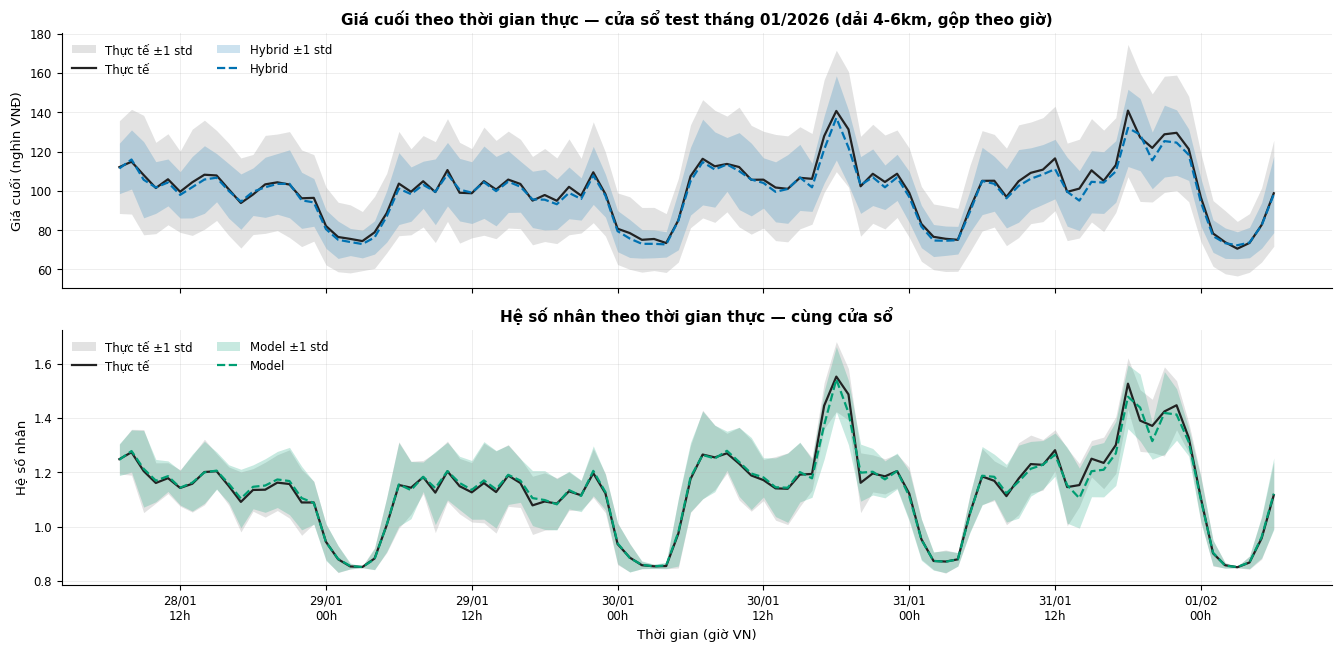

In [6]:
b1 = ev[(ev.thang == "2026-01") & (ev.quang_duong >= 4) & (ev.quang_duong <= 6)].copy()
b1["gio_tron"] = b1.tg_vn.dt.floor("h")
gg = b1.groupby("gio_tron")
mt, st   = gg.gia_that.mean(),  gg.gia_that.std()
mh, sh   = gg.hybrid_dd.mean(), gg.hybrid_dd.std()
mt2, st2 = gg.heso_that.mean(), gg.heso_that.std()
mh2, sh2 = gg.heso_dd.mean(),   gg.heso_dd.std()
x = mt.index

fig, ax = plt.subplots(2, 1, figsize=(13.5, 6.6), sharex=True)
ax[0].fill_between(x, (mt-st)/1000, (mt+st)/1000, color=INK, alpha=0.13, lw=0, label="Thực tế ±1 std")
ax[0].plot(x, mt/1000, color=INK, lw=1.6, label="Thực tế", zorder=5)
ax[0].fill_between(x, (mh-sh)/1000, (mh+sh)/1000, color=BLUE, alpha=0.20, lw=0, label="Hybrid ±1 std")
ax[0].plot(x, mh/1000, color=BLUE, lw=1.6, ls="--", label="Hybrid", zorder=5)
ax[0].set_ylabel("Giá cuối (nghìn VNĐ)")
ax[0].set_title("Giá cuối theo thời gian thực — cửa sổ test tháng 01/2026 (dải 4-6km, gộp theo giờ)", fontweight="bold")
ax[0].legend(frameon=False, ncol=2, loc="upper left")

ax[1].fill_between(x, mt2-st2, mt2+st2, color=INK, alpha=0.13, lw=0, label="Thực tế ±1 std")
ax[1].plot(x, mt2, color=INK, lw=1.6, label="Thực tế", zorder=5)
ax[1].fill_between(x, mh2-sh2, mh2+sh2, color=GREEN, alpha=0.22, lw=0, label="Model ±1 std")
ax[1].plot(x, mh2, color=GREEN, lw=1.6, ls="--", label="Model", zorder=5)
ax[1].set_ylabel("Hệ số nhân"); ax[1].set_xlabel("Thời gian (giờ VN)")
ax[1].set_title("Hệ số nhân theo thời gian thực — cùng cửa sổ", fontweight="bold")
ax[1].legend(frameon=False, ncol=2, loc="upper left")
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m\n%Hh"))

plt.tight_layout(); plt.savefig(HINH / "U2_chuoi_thoigian_std.png"); plt.show()

## 5. Hình U3 — So sánh model: MAE theo giờ + phân bố sai số

Trả lời trực tiếp *"plot khi so sánh các model"*: thay vì 1 con số MAE tổng, xem model sai **ở giờ
nào** và phân bố sai số **rộng bao nhiêu**.

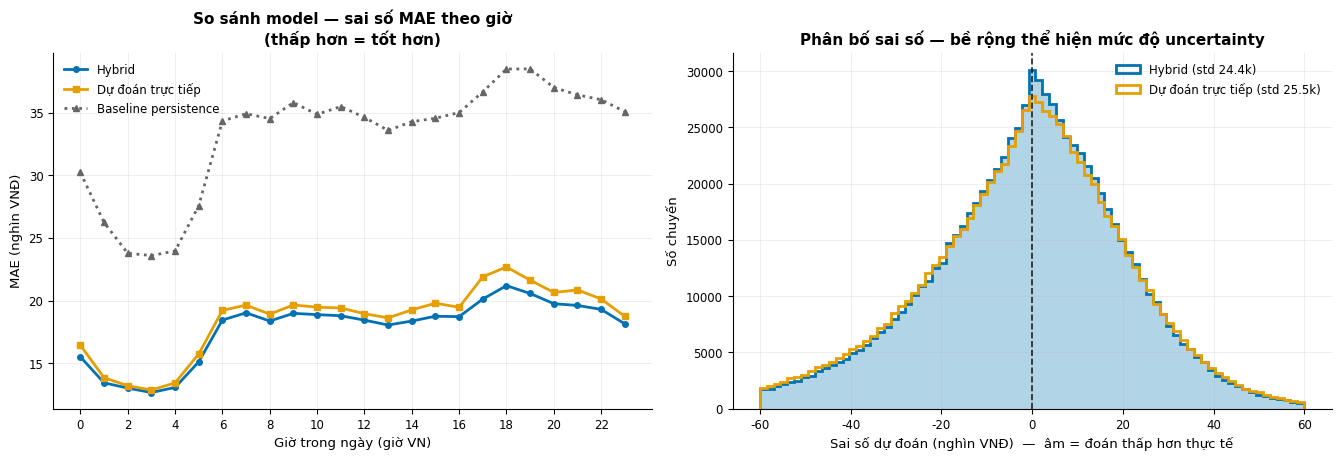

Hybrid thang truc tiep o 24/24 gio
MAE Hybrid: thap nhat 12,655 (gio 3h) | cao nhat 21,186 (gio 18h)
  -> uncertainty thay doi 1.67 lan giua gio thap nhat va cao nhat
Bias TB: Hybrid -2,298 | Truc tiep -2,939


In [7]:
g2 = ev.groupby("gio_vn")
mae_hyb = g2.e_hyb.apply(lambda s: s.abs().mean())
mae_tt  = g2.e_tt.apply(lambda s: s.abs().mean())
mae_per = g2.e_per.apply(lambda s: s.abs().mean())

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.7))
hh = mae_hyb.index
ax[0].plot(hh, mae_hyb/1000, color=BLUE,   lw=2, marker="o", ms=4, label="Hybrid")
ax[0].plot(hh, mae_tt/1000,  color=ORANGE, lw=2, marker="s", ms=4, label="Dự đoán trực tiếp")
ax[0].plot(hh, mae_per/1000, color=MUT,    lw=2, ls=":", marker="^", ms=4, label="Baseline persistence")
ax[0].set_xlabel("Giờ trong ngày (giờ VN)"); ax[0].set_ylabel("MAE (nghìn VNĐ)")
ax[0].set_title("So sánh model — sai số MAE theo giờ\n(thấp hơn = tốt hơn)", fontweight="bold")
ax[0].set_xticks(range(0, 24, 2)); ax[0].legend(frameon=False)

bins = np.linspace(-60000, 60000, 80)
ax[1].hist(ev.e_hyb, bins=bins, color=BLUE, alpha=0.30, lw=0)
ax[1].hist(ev.e_hyb, bins=bins, histtype="step", color=BLUE, lw=2,
           label=f"Hybrid (std {ev.e_hyb.std()/1000:.1f}k)")
ax[1].hist(ev.e_tt, bins=bins, histtype="step", color=ORANGE, lw=2,
           label=f"Dự đoán trực tiếp (std {ev.e_tt.std()/1000:.1f}k)")
ax[1].axvline(0, color=INK, lw=1.2, ls="--")
ax[1].set_xlabel("Sai số dự đoán (nghìn VNĐ)  —  âm = đoán thấp hơn thực tế")
ax[1].set_ylabel("Số chuyến")
ax[1].set_title("Phân bố sai số — bề rộng thể hiện mức độ uncertainty", fontweight="bold")
ax[1].set_xticks(np.arange(-60000, 60001, 20000))
ax[1].set_xticklabels([f"{int(v/1000)}" for v in np.arange(-60000, 60001, 20000)])
ax[1].legend(frameon=False)

plt.tight_layout(); plt.savefig(HINH / "U3_sosanh_model_saiso.png"); plt.show()

print(f"Hybrid thang truc tiep o {int((mae_hyb < mae_tt).sum())}/24 gio")
print(f"MAE Hybrid: thap nhat {mae_hyb.min():,.0f} (gio {mae_hyb.idxmin()}h) | cao nhat {mae_hyb.max():,.0f} (gio {mae_hyb.idxmax()}h)")
print(f"  -> uncertainty thay doi {mae_hyb.max()/mae_hyb.min():.2f} lan giua gio thap nhat va cao nhat")
print(f"Bias TB: Hybrid {ev.e_hyb.mean():,.0f} | Truc tiep {ev.e_tt.mean():,.0f}")

## 6. Hình U4 — Bất đối xứng uncertainty: giá cơ bản vs hệ số nhân

Đây là phần trực quan hoá **sàn nhiễu** (ý 4 của mentor). Hai câu hỏi:

1. Uncertainty tương đối của **giá cơ bản** so với **hệ số nhân** chênh nhau bao nhiêu?
2. Model có **tái tạo được độ dao động thật** không, hay dự đoán quá "phẳng"?

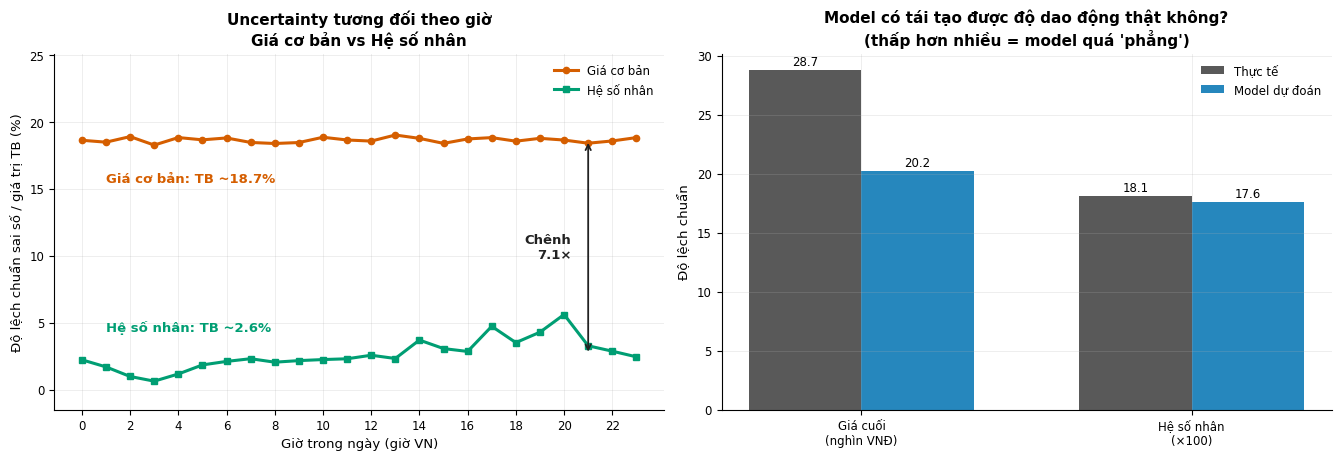

CV sai so: gia co ban 18.66% | he so nhan 2.63% -> chenh 7.1x
Ty le tai tao dao dong: gia 0.703 | he so nhan 0.971


In [8]:
gb = band.groupby("gio_vn")
cv_base = gb.apply(lambda d: (d.gia_coban_dd - d.gia_coban_that).std() / d.gia_coban_that.mean() * 100)
cv_mult = gb.apply(lambda d: (d.heso_dd - d.heso_that).std() / d.heso_that.mean() * 100)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.7))
hb = cv_base.index
ax[0].plot(hb, cv_base, color=RED,   lw=2.2, marker="o", ms=4.5, label="Giá cơ bản")
ax[0].plot(hb, cv_mult, color=GREEN, lw=2.2, marker="s", ms=4.5, label="Hệ số nhân")
ax[0].set_xlabel("Giờ trong ngày (giờ VN)"); ax[0].set_ylabel("Độ lệch chuẩn sai số / giá trị TB (%)")
ax[0].set_title("Uncertainty tương đối theo giờ\nGiá cơ bản vs Hệ số nhân", fontweight="bold")
ax[0].set_xticks(range(0, 24, 2)); ax[0].set_ylim(-1.5, cv_base.max() * 1.32)
ax[0].legend(frameon=False, loc="upper right")
ax[0].text(1.0, cv_base.mean() - 2.4, f"Giá cơ bản: TB ~{cv_base.mean():.1f}%", color=RED,   fontsize=9.5, fontweight="bold", va="top")
ax[0].text(1.0, cv_mult.mean() + 1.5, f"Hệ số nhân: TB ~{cv_mult.mean():.1f}%", color=GREEN, fontsize=9.5, fontweight="bold", va="bottom")
ax[0].annotate("", xy=(21.0, cv_base.mean()), xytext=(21.0, cv_mult.mean()),
               arrowprops=dict(arrowstyle="<->", color=INK, lw=1.3))
ax[0].text(20.3, (cv_base.mean() + cv_mult.mean())/2, f"Chênh\n{cv_base.mean()/cv_mult.mean():.1f}×",
           ha="right", va="center", fontsize=9.5, fontweight="bold", color=INK)

sd_that, sd_hyb = band.gia_that.std(), band.hybrid_dd.std()
sd_ht,   sd_hd  = band.heso_that.std(), band.heso_dd.std()
xx, w = np.arange(2), 0.34
b1_ = ax[1].bar(xx - w/2, [sd_that/1000, sd_ht*100], w, color=INK,  alpha=0.75, label="Thực tế")
b2_ = ax[1].bar(xx + w/2, [sd_hyb/1000,  sd_hd*100], w, color=BLUE, alpha=0.85, label="Model dự đoán")
for b in list(b1_) + list(b2_):
    ax[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.4, f"{b.get_height():.1f}", ha="center", fontsize=8.5)
ax[1].set_xticks(xx); ax[1].set_xticklabels(["Giá cuối\n(nghìn VNĐ)", "Hệ số nhân\n(×100)"])
ax[1].set_ylabel("Độ lệch chuẩn")
ax[1].set_title("Model có tái tạo được độ dao động thật không?\n(thấp hơn nhiều = model quá 'phẳng')", fontweight="bold")
ax[1].legend(frameon=False)

plt.tight_layout(); plt.savefig(HINH / "U4_uncertainty_batdoixung.png"); plt.show()

print(f"CV sai so: gia co ban {cv_base.mean():.2f}% | he so nhan {cv_mult.mean():.2f}% -> chenh {cv_base.mean()/cv_mult.mean():.1f}x")
print(f"Ty le tai tao dao dong: gia {sd_hyb/sd_that:.3f} | he so nhan {sd_hd/sd_ht:.3f}")

## 7. Tổng hợp số liệu đã trích vào báo cáo (mục 5)

In [9]:
print("=" * 62)
print("SO LIEU TRICH VAO MUC 5 BAO CAO TUAN 2")
print("=" * 62)
print(f"[U1] Bien do gia cuoi theo gio : {(m_that.max()/m_that.min()-1)*100:.1f}%")
print(f"[U1] Bien do he so nhan theo gio: {(m_ht.max()/m_ht.min()-1)*100:.1f}%")
print(f"[U1] Model gia   HEP HON thuc te: {(1-s_hyb.mean()/s_that.mean())*100:.1f}%")
print(f"[U1] Model heso  HEP HON thuc te: {(1-s_hd.mean()/s_ht.mean())*100:.1f}%")
print(f"[U3] Hybrid thang truc tiep     : {int((mae_hyb < mae_tt).sum())}/24 gio")
print(f"[U3] MAE min {mae_hyb.min():,.0f} (gio {mae_hyb.idxmin()}h) -> max {mae_hyb.max():,.0f} (gio {mae_hyb.idxmax()}h) = {mae_hyb.max()/mae_hyb.min():.2f}x")
print(f"[U3] std sai so: Hybrid {ev.e_hyb.std():,.0f} | Truc tiep {ev.e_tt.std():,.0f}")
print(f"[U3] Bias TB   : Hybrid {ev.e_hyb.mean():,.0f} | Truc tiep {ev.e_tt.mean():,.0f}")
print(f"[U4] CV sai so : gia co ban {cv_base.mean():.2f}% vs he so nhan {cv_mult.mean():.2f}% = {cv_base.mean()/cv_mult.mean():.1f}x")
print(f"[U4] Tai tao dao dong: gia {sd_hyb/sd_that*100:.1f}% | he so nhan {sd_hd/sd_ht*100:.1f}%")
print("=" * 62)
print(f"\n4 hinh da luu vao: {HINH.resolve()}")

SO LIEU TRICH VAO MUC 5 BAO CAO TUAN 2
[U1] Bien do gia cuoi theo gio : 64.2%
[U1] Bien do he so nhan theo gio: 58.6%
[U1] Model gia   HEP HON thuc te: 38.2%
[U1] Model heso  HEP HON thuc te: 3.9%
[U3] Hybrid thang truc tiep     : 24/24 gio
[U3] MAE min 12,655 (gio 3h) -> max 21,186 (gio 18h) = 1.67x
[U3] std sai so: Hybrid 24,426 | Truc tiep 25,476
[U3] Bias TB   : Hybrid -2,298 | Truc tiep -2,939
[U4] CV sai so : gia co ban 18.66% vs he so nhan 2.63% = 7.1x
[U4] Tai tao dao dong: gia 70.3% | he so nhan 97.1%

4 hinh da luu vao: C:\Users\Admin\OneDrive\Máy tính\Pricing_Reseach_Vin AI\TP_HCM_data\docs\hinh_anh


---

## 8. ⏳ CHƯA LÀM — Bổ sung model P6 / P7 của nhánh point-price (việc A5)

Mentor nói *"so sánh **các model**"*. Hiện U3 mới so 3 model của **hướng A** (Hybrid, trực tiếp,
persistence). Model **P6 CatBoost** và **P7 Residual CatBoost** của nhánh point-price **chưa có mặt
trên cùng trục toạ độ**.

**Cần bạn phụ trách nhánh point-price xuất 1 file** với các cột sau, trên đúng tập test:

| Cột | Kiểu | Ghi chú |
|---|---|---|
| `target_timestamp` | datetime | để vẽ theo thời gian |
| `target_shown_price` | float | giá thực tế |
| `pred_p6` | float | dự đoán của P6 CatBoost |
| `pred_p7` | float | dự đoán của P7 Residual (nếu có) |
| `evaluation_month` | str | để đối chiếu fold |

**Lưu ý về khả năng so sánh:** 2 nhánh dùng **tập test khác nhau** (hướng A: 864.360 dòng — hướng B:
216.090 dòng nominal test). Nên khi ghép biểu đồ phải **ghi rõ** điều này, hoặc tốt hơn là chạy lại
cả 2 model trên **cùng một tập test** thì con số mới so sánh trực tiếp được.

Sau khi có file, thêm 2 dòng vào cell vẽ U3:
```python
ax[0].plot(hh, mae_p6/1000, color=PURPLE, lw=2, marker="D", ms=4, label="P6 CatBoost")
ax[0].plot(hh, mae_p7/1000, color=RED,    lw=2, marker="v", ms=4, label="P7 Residual")
```